# The 37-Second Blind Spot
## A Million Green Tests, One Missing Assumption
**Ethical Tech CoLab | Retrospective synthetic study | 4 October 2026**

Inspired by [Channi Greenwall's article](https://www.linkedin.com/pulse/ten-years-flawless-flights-proved-nothing-software-ariane-greenwall-sc5he/). The [1996 inquiry](https://www-users.cse.umn.edu/~arnold/disasters/ariane5rep.html) says representative ground tests would have exposed the Ariane 501 failure and post-flight simulations reproduced it. **Hypothesis:** representative simulation and AI-assisted test design could uncover an Ariane 501-like failure before deployment. We test the required conditions: **when does Monte Carlo find a known defect, and what must be true for the finding to become actionable?**

This is not flight telemetry, original Ada software, an exact reconstruction, or a blinded AI-discovery experiment. BH values are invented conversion units, not metres per second. H0 + 36.7 s is about 30 s after lift-off. Read [the study](docs/STUDY.md) and [methods](docs/METHODS.md) for evidence and limitations.

Alternative web search located candidate sources; relevant claims were checked against directly retrieved source text. The [source catalog](data/sources.json) records the university-hosted inquiry, independent CNES chronology, ESA access limits, and metadata-only checks.

Select the local `.venv` Python kernel and **Run All**. Optional dependencies are in `requirements.txt`. The first cell recomputes 1.6 million opportunities and the deterministic prerequisite grid; the latter adds no random draws.

In [1]:
import json
from pathlib import Path
from IPython.display import SVG, display
from blind_spot.experiments import run_study

root = Path.cwd()
assert (root / 'results' / 'study.json').is_file(), 'Run from the repository root'
results = run_study()
published = json.loads((root / 'results' / 'study.json').read_text(encoding='utf-8'))
assert results == published, 'Computed results differ from the published study'
print('Reproduced opportunities:', sum(row['n'] for row in results['monte_carlo']))
print('Data:', results['data_class'])
print('Seed:', results['seed'])

Reproduced opportunities: 1600000
Data: synthetic; no flight telemetry
Seed: 5011996


The study reproduces **1,600,000** independent synthetic test opportunities, not 1,600,000 launches. Its exact-match assertion is a reproducibility check, not evidence that the model matches a real vehicle. We knew the published mechanism before constructing this model.

The legacy profile samples BH uniformly from 0 to 30000; expanded support uses 0 to 65535. Both sample time independently from 0 to 80 seconds. Alignment is active before 40 seconds. The rare-tail profile deliberately assigns a 0.1% chance to overflow-range BH. These distributions are not measured historical conditions.

million_legacy: 0/1,000,000; navigation losses=0; 95% Wilson=[0.000000%, 0.000384%]
expanded_faithful: 25,005/100,000; navigation losses=25,005; 95% Wilson=[24.737567%, 25.274354%]
rare_tail_faithful: 96/200,000; navigation losses=96; 95% Wilson=[0.039312%, 0.058607%]
expanded_idealized_stub: 0/100,000; navigation losses=0; 95% Wilson=[0.000000%, 0.003841%]
expanded_packet_oracle: 0/100,000; navigation losses=25,005; 95% Wilson=[0.000000%, 0.003841%]
expanded_alignment_removed: 0/100,000; navigation losses=0; 95% Wilson=[0.000000%, 0.003841%]


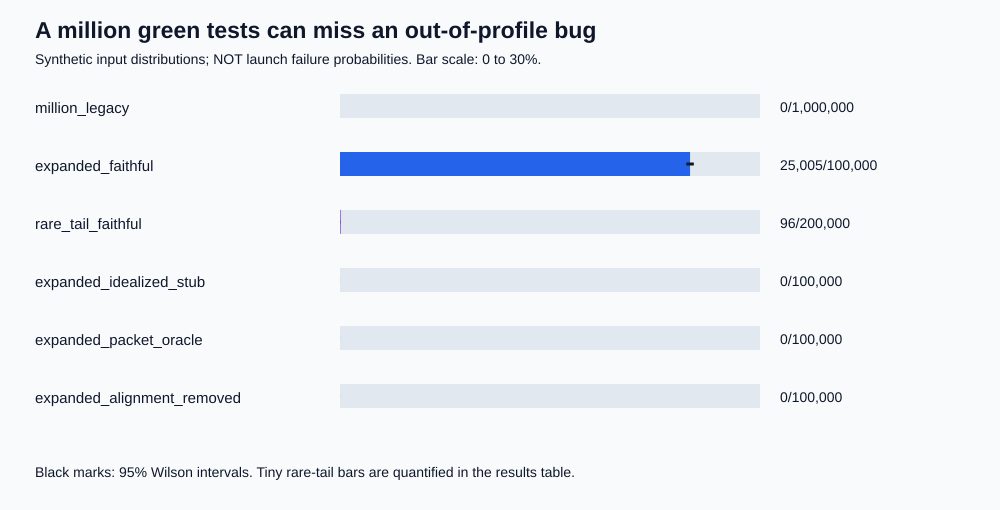

In [2]:
for row in results['monte_carlo']:
    low, high = row['wilson_95']
    print(f"{row['name']}: {row['detected']:,}/{row['n']:,}; "
          f"navigation losses={row['navigation_losses']:,}; "
          f"95% Wilson=[{low:.6%}, {high:.6%}]")
display(SVG(filename=str(root / 'results' / 'monte_carlo.svg')))

**A million legacy-like samples detect nothing**, because their support excludes the conversion boundary. Expanded faithful tests detect **25,005/100,000**, while rare-tail tests detect **96/200,000**. The intervals quantify sampling uncertainty only.

The expanded stub and packet-oracle experiments use the exact same random inputs as the faithful run. A stub omits the bug; a packet-presence oracle overlooks **25,005 navigation losses**. Removing alignment also produces zero detections, but for a different reason: the modeled causal path is blocked. A green result alone cannot distinguish a repair from an inadequate test.

p = 0.0 | tests for 95% detection = None
p = 1e-06 | tests for 95% detection = 2995731
p = 0.0005 | tests for 95% detection = 5990
p = 0.01 | tests for 95% detection = 299
p = 0.25 | tests for 95% detection = 11
Exact one-sided 95% upper bound after a million zeros: 2.99572778635e-06


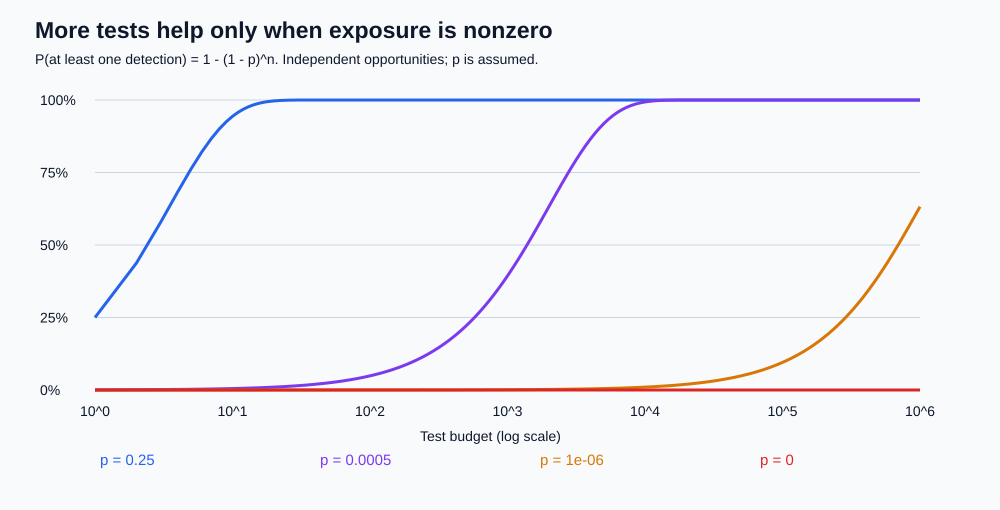

In [3]:
for row in results['probability_table']:
    print('p =', row['p'], '| tests for 95% detection =', row['tests_for_95_percent'])
print('Exact one-sided 95% upper bound after a million zeros:',
      results['monte_carlo'][0]['zero_failure_upper_95'])
display(SVG(filename=str(root / 'results' / 'detection_probability.svg')))

For independent tests, `P(detect at least once) = 1 - (1-p)^n`. At **p=0.25**, 11 tests give at least 95% discovery probability. At **p=0.0005**, the budget is **5,990**; at **p=0.000001**, it is **2,995,731**. At zero exposure, no finite budget works.

The million-zero upper bound is approximately **2.996 per million** under that same input distribution and a valid oracle. It does not transfer to another trajectory distribution, quantify model error, or establish a posterior probability that a system is safe.

In [4]:
for name, suite in results['coverage']['suites'].items():
    print(name, '| cases:', suite['cases'], '| pairs:', suite['pairs_covered'],
          '| navigation losses:', suite['navigation_losses'], '| detected:', suite['detected'])
assert results['coverage']['suites']['pairwise_blind_witness']['pair_coverage'] == 1.0
assert results['coverage']['suites']['pairwise_blind_witness']['navigation_losses'] == 0

exhaustive | cases: 256 | pairs: 112 | navigation losses: 4 | detected: 2
greedy_pairwise | cases: 8 | pairs: 112 | navigation losses: 0 | detected: 0
pairwise_blind_witness | cases: 8 | pairs: 112 | navigation losses: 0 | detected: 0


All **256** Boolean configurations yield four navigation losses, two detected by their configured oracle. Both eight-case pairwise suites cover **112/112 pairs** and miss the losses. The blind witness was deliberately assembled from non-failing candidates; it is a logical counterexample, not an estimate of typical testing-tool performance.

Crossing design and harness switches creates a high-order conjunction. Those switches were fixed in the real accident. This does not mean Ariane 501 historically required a high-dimensional search: representative input replay could have exposed it.

baseline_identical_pair | halted: 2 | navigation: False | unsafe command: True
one_unit | halted: 1 | navigation: False | unsafe command: True
three_identical_units | halted: 3 | navigation: False | unsafe command: True
remove_postlaunch_alignment | halted: 0 | navigation: True | unsafe command: False
guard_alignment_conversion | halted: 0 | navigation: True | unsafe command: False
isolate_alignment_exception | halted: 0 | navigation: True | unsafe command: False
reject_diagnostic_frame | halted: 2 | navigation: False | unsafe command: False
idealized_sri_stub | halted: 0 | navigation: True | unsafe command: False


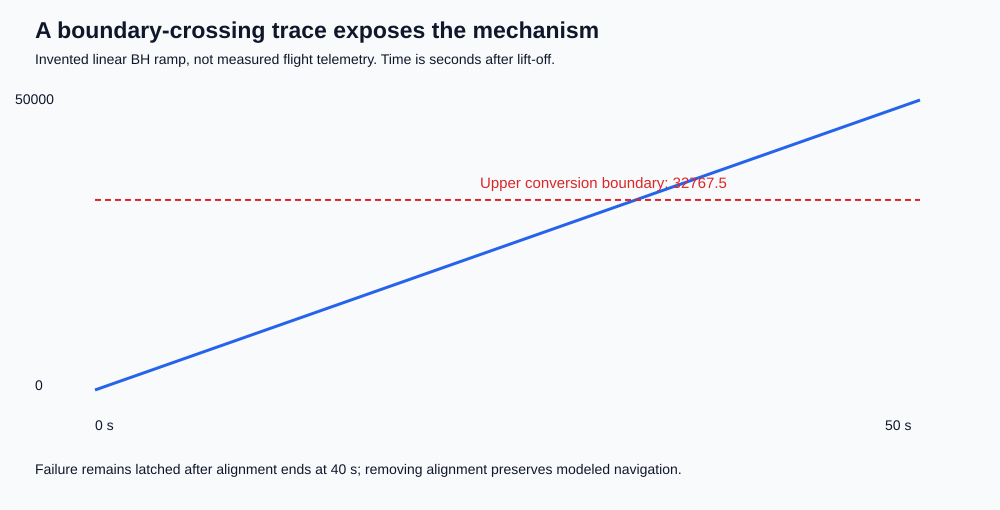

In [5]:
for row in results['ablations']:
    print(row['name'], '| halted:', row['failed_units'],
          '| navigation:', row['navigation_available'], '| unsafe command:', row['unsafe_command'])
display(SVG(filename=str(root / 'results' / 'synthetic_trace.svg')))

One, two, and three identical units all share the deterministic defect. Rejecting diagnostic frames avoids the modeled unsafe command but **does not restore navigation**. Removing unnecessary alignment, guarding its conversion, or isolating its exception blocks this modeled chain; none is a certified flight fix.

The plot is an **invented linear BH trace**. It crosses the conversion boundary at sampled time 32.8 seconds and remains failed after the 40-second alignment cutoff. It was not fitted to the historical failure time and contains no physical trajectory dynamics.

## What would have to be true for this failure mode to be uncovered?

The next experiment removes seven test-process prerequisites one at a time and enumerates every joint combination. The injected witness tests exposure, lifecycle, executable fidelity, and oracle quality. A separate analytic rare-tail campaign tests the budget. Retained replay evidence and an enforced Boolean response are downstream of detection. The guarded negative control keeps all prerequisites but removes the defect's effect.

This is a controlled mechanism experiment, not a blind AI-discovery trial or a measurement of human action. The 128 configurations are designed cases, not new Monte Carlo samples.

Joint prerequisite grid: {'cases': 128, 'actual_navigation_losses': 32, 'injected_detections': 8, 'replayable_findings': 4, 'modeled_response_blocks': 2, 'discovery_target_met': 4, 'response_target_met': 1}
All prerequisites present | actual loss: True | injected detection: True | budget: 5990 | campaign chance: 95.000084% | modeled block: True
No overflow exposure | actual loss: False | injected detection: False | budget: 5990 | campaign chance: 0.000000% | modeled block: False
Wrong lifecycle only | actual loss: False | injected detection: False | budget: 5990 | campaign chance: 0.000000% | modeled block: False
Idealized SRI stub | actual loss: True | injected detection: False | budget: 5990 | campaign chance: 0.000000% | modeled block: False
Packet-only oracle | actual loss: True | injected detection: False | budget: 5990 | campaign chance: 0.000000% | modeled block: False
Too little random budget | actual loss: True | injected detection: True | budget: 10 | campaign chance: 0.49887

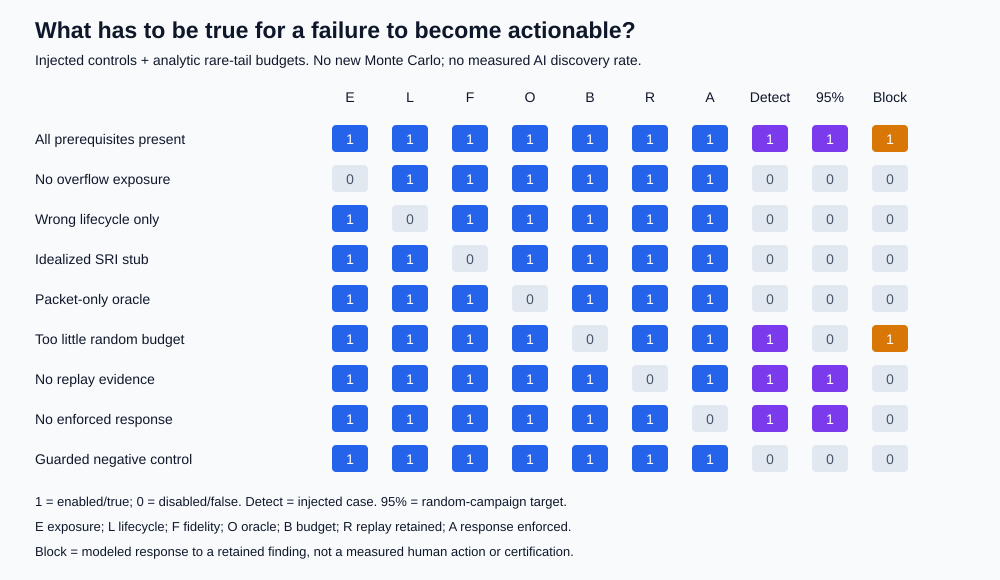

In [6]:
from blind_spot.model import Design, Stimulus, evaluate, oracle_detects
from blind_spot.statistics import detection_probability

readiness = results['detection_readiness']
print('Joint prerequisite grid:', readiness['summary'])
for row in readiness['ablations']:
    print(row['name'], '| actual loss:', row['actual_navigation_loss'],
          '| injected detection:', row['injected_control_detected'],
          '| budget:', row['campaign_budget'],
          '| campaign chance:', f"{row['campaign_detection_probability']:.6%}",
          '| modeled block:', row['modeled_response_blocks'])
case = readiness['ablations'][0]['replay_case']
assert oracle_detects(evaluate(Stimulus(**case['stimulus']), Design(**case['design'])), case['oracle'])
n95 = readiness['target_budget']
assert detection_probability(readiness['base_detection_p'], n95) >= 0.95
assert detection_probability(readiness['base_detection_p'], n95 - 1) < 0.95
assert readiness['summary']['cases'] == 128
display(SVG(filename=str(root / 'results' / 'detection_readiness.svg')))

**The seven-switch grid has 128 configurations:** 32 actual navigation losses, 8 injected detections, 4 replayable findings, and 2 modeled response blocks. Four configurations meet the conditional 95% discovery target; one also retains evidence and enforces the response. These are truth-table counts, not an AI discovery rate or readiness percentage.

For the fixed vulnerable design, exposure AND active lifecycle AND faithful semantics AND a safety oracle are necessary and sufficient for the injected dynamic witness. A guarded negative control must not be reported as navigation loss. That claim is restricted to this route; source review or static reasoning might discover the defect differently.

The 10-test control still detects the intentionally injected fault and can block under the modeled policy. Its separate random campaign has only about 0.499% discovery probability at p=0.0005; the minimal 95% budget is 5,990. A sufficient budget for a target is not necessary for a lucky single detection and does not guarantee detection.

Dropping replay retention or response leaves detection intact while breaking the path to an actionable decision. The saved positive-control witness executes again above. Whether a real person understands, owns, and acts on that evidence remains unmeasured. See the [exact conditions](docs/METHODS.md#detection-readiness-experiment) and [future-testing protocol](docs/FRAMEWORK.md#design-a-detection-readiness-experiment).

### Q&A
**Would representative tests have caught Ariane 501?** The inquiry says suitable ground tests would have exposed it and post-flight simulations reproduced it. **Does Monte Carlo automatically solve human blind spots?** No: our million narrow-profile passes and masked-oracle runs construct counterexamples. **Would AI have discovered it?** This experiment does not measure that; a blinded, uncontaminated comparison is required.

**What would have to be true for this type of failure to be uncovered?** For the tested dynamic route: joint exposure during the vulnerable lifecycle, preserved executable semantics, and a meaningful oracle. Random discovery additionally needs a justified probability model and budget for the chosen target. Actionable response needs retained evidence and an enforced decision process, which is modeled rather than empirically validated here.

### Data Analysis Key Findings
- Expanded faithful testing detects 25,005/100,000 failures; the same inputs yield zero detections with an idealized stub or a packet-only oracle.
- The rare-tail run detects 96/200,000; discovery budget depends on assumed exposure, not merely test volume.
- Full pair coverage can coexist with zero observed defects: the eight-case witness covers 112 pairs but misses all navigation losses.
- The separate 128-row prerequisite grid yields 8 injected detections but only 2 modeled response blocks; replay and enforcement do not follow automatically from detection. No extra Monte Carlo draws were added.

### Insights or Next Steps
- Use the [detection-readiness protocol](docs/FRAMEWORK.md#design-a-detection-readiness-experiment): positive and protected controls, one-prerequisite removals, joint gates, a defensible budget, a replay record, and an observable response.
- Run this notebook yourself, then replace the synthetic assumptions only when justified data are available. Use unseen variants, not this famous case, to evaluate independent AI discovery.